<a href="https://colab.research.google.com/github/shubhiv02-learner/banking-log-anomaly-detection/blob/main/SentinelIQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# SentinelIQ V1.0
# Statistical Observability Platform
# ============================================================

# This project simulates a banking observability pipeline
# capable of detecting infrastructure anomalies before
# they affect critical financial systems.
#
# Core Techniques Used:
# - EWMA Drift Detection
# - CUSUM Anomaly Detection
# - Persistence Scoring
# - Correlation Analysis
# - Bayesian Incident Prioritization
#
# Author: Shubhi Verma
# Environment: Google Colab / Jupyter Notebook
# ============================================================


# =========================
# STEP 1 — IMPORT LIBRARIES
# =========================

# Pandas -> Data manipulation
# NumPy -> Numerical operations
# PyPlot -> Dashboard visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as pyplot
import warnings
import os

warnings.filterwarnings("ignore")

# Create output directory
os.makedirs("outputs", exist_ok=True)





Generating Synthetic Banking Logs...


Synthetic banking logs generated.

            timestamp  latency_ms  error_count  cpu_usage
0 2026-01-01 00:00:00  124.967142            1  57.797885
1 2026-01-01 00:01:00  118.617357            2  50.932348
2 2026-01-01 00:02:00  126.476885            1  54.493109
3 2026-01-01 00:03:00  135.230299            5  52.536136
4 2026-01-01 00:04:00  117.658466            1  68.167690
Applying EWMA Detection...

EWMA detection completed.

Applying CUSUM Detection...

CUSUM detection completed.

Calculating Persistence Scores...

Persistence scoring completed.

Running Correlation Analysis...


Correlation Matrix:

             latency_ms  error_count  cpu_usage
latency_ms     1.000000     0.639623   0.527052
error_count    0.639623     1.000000   0.553160
cpu_usage      0.527052     0.553160   1.000000
Applying Bayesian Prioritization...

Generating Monitoring Dashboard...



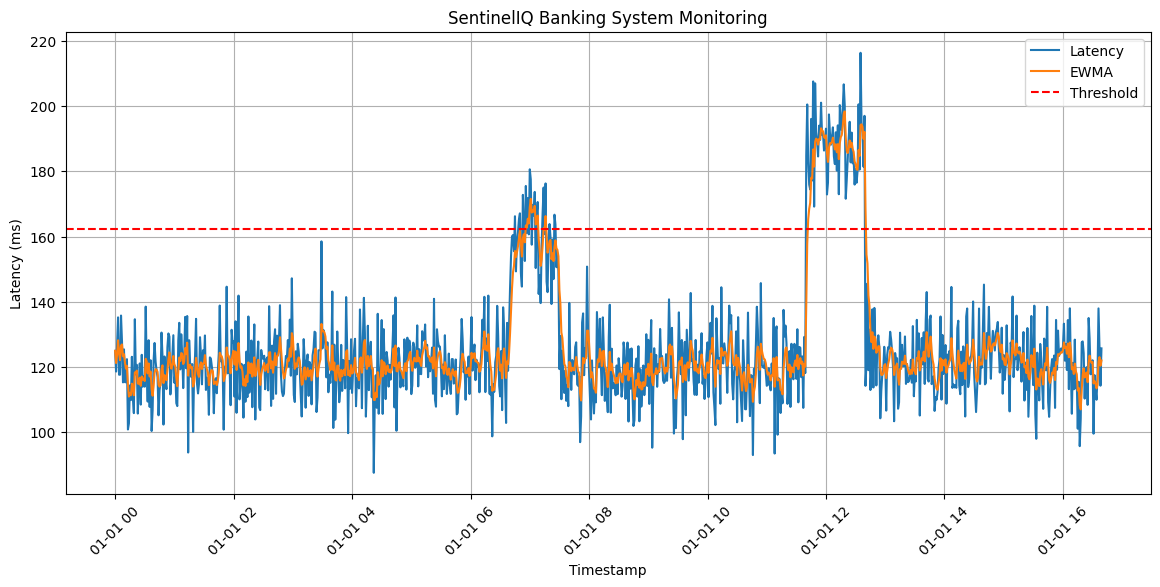

Generating Executive Summary...



    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------

    Critical Incidents : 29

    Medium Incidents   : 399

    Observations:
    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:
    Investigate payment processing systems
    and infrastructure resource utilization.

    

Pipeline Execution Completed.



In [ ]:
# ============================================================
# STEP 2 — GENERATE SYNTHETIC BANKING LOGS
# ============================================================

def generate_synthetic_logs(rows=1000):

    """
    Generates synthetic banking infrastructure logs.

    The dataset simulates operational metrics collected
    from banking systems such as:
    - API latency
    - Transaction processing errors
    - CPU utilization

    Artificial anomaly windows are injected intentionally
    to mimic real-world degradation scenarios.

    Parameters:
    -----------
    rows : int
        Number of log entries to generate

    Returns:
    --------
    df : pandas.DataFrame
        Simulated banking observability dataset
    """

    # Ensure reproducible results
    np.random.seed(42)

    # --------------------------------------------------------
    # Generate timestamps
    # --------------------------------------------------------
    # Creates one log entry per minute
    # Example:
    # 2026-01-01 00:00:00
    # 2026-01-01 00:01:00
    # --------------------------------------------------------

    timestamps = pd.date_range(
        start='2026-01-01',
        periods=rows,
        freq='min'
    )

    # --------------------------------------------------------
    # Generate normal banking latency behavior
    # --------------------------------------------------------
    # Average API latency = 120 ms
    # Standard deviation = 10
    #
    # This simulates normal transaction processing times
    # observed in payment gateways or banking APIs.
    # --------------------------------------------------------

    latency = np.random.normal(
        loc=120,
        scale=10,
        size=rows
    )

    # --------------------------------------------------------
    # Inject anomaly windows
    # --------------------------------------------------------
    # Window 1:
    # Mild infrastructure degradation
    #
    # Window 2:
    # Severe operational instability
    #
    # These anomalies simulate:
    # - payment processing slowdown
    # - infrastructure overload
    # - API congestion
    # --------------------------------------------------------

    latency[400:450] += 40
    latency[700:760] += 70

    # --------------------------------------------------------
    # Generate application error counts
    # --------------------------------------------------------
    # Simulates:
    # - failed transactions
    # - API failures
    # - timeout exceptions
    # - Normal errors: ~2
    # --------------------------------------------------------

    errors = np.random.poisson(
        lam=2,
        size=rows
    )

    # Inject elevated error rates in  temporary “incident window”  by count of 8
    errors[700:760] += 8

    # --------------------------------------------------------
    # Generate CPU utilization metrics
    # --------------------------------------------------------
    # Simulates backend infrastructure resource usage
    # --------------------------------------------------------

    cpu = np.random.normal(
        loc=55,
        scale=5,
        size=rows
    )

    # Inject CPU saturation window
    cpu[700:760] += 20

    # --------------------------------------------------------
    # Create consolidated observability dataset
    # --------------------------------------------------------

    df = pd.DataFrame({

        "timestamp": timestamps,

        "latency_ms": latency,

        "error_count": errors,

        "cpu_usage": cpu
    })

    # Save dataset for reproducibility
    df.to_csv(
        "outputs/synthetic_logs.csv",
        index=False
    )

    print("\nSynthetic banking logs generated.\n")

    return df


# ============================================================
# STEP 3 — EWMA DRIFT DETECTION
# ============================================================

def apply_ewma_detection(df, alpha=0.3):

    """
    Applies EWMA anomaly detection.

    EWMA helps detect gradual operational drift
    before systems cross critical thresholds.

    Parameters:
    -----------
    df : pandas.DataFrame
        Banking observability dataset

    alpha : float
        EWMA smoothing factor
        typically between 0 and 1, which dictates how quickly the average adapts to new data
        Higher the value it reacts faster to recent changes

    Returns:
    --------
    df : pandas.DataFrame
        Updated dataframe with EWMA metrics

    threshold : float
        Dynamic anomaly threshold
    """

    # Compute EWMA latency trend
    df['ewma_latency'] = (
        df['latency_ms']
        .ewm(alpha=alpha)
        .mean()
    )

    """
    e.g. Mean: 100 Std Dev: 10  Threshold: (100 + (2*10))= 120ms
    If the EWMA trend hits 125ms, the code flags it because it has moved significantly further than the usual "wiggle" room.
    """
    # Dynamic anomaly threshold
    threshold = (
        df['ewma_latency'].mean()
        +
        2 * df['ewma_latency'].std()
    )

    # Flag anomalous drift regions
    df['ewma_alert'] = (
        df['ewma_latency'] > threshold
    )

    print("EWMA detection completed.\n")

    return df, threshold


# ============================================================
# STEP 4 — CUSUM DETECTION
# ============================================================

def apply_cusum_detection(df, k=5):

    """
    Applies CUSUM detection.

    CUSUM identifies cumulative deviations
    from normal operational behavior.

    Useful for:
    - silent degradation
    - queue accumulation
    - sustained instability
    """

    target = df['latency_ms'].mean()

    cusum = [0]

    for x in df['latency_ms'][1:]:

        s = max(
            0,
            cusum[-1] + (x - target - k)
        )

        cusum.append(s)

    df['cusum'] = cusum

    # Alert threshold
    df['cusum_alert'] = (
        df['cusum'] > 50
    )

    print("CUSUM detection completed.\n")

    return df


# ============================================================
# STEP 5 — PERSISTENCE SCORING
# ============================================================

def calculate_persistence_score(df):

    """
    Measures anomaly persistence duration.

    Persistent anomalies are treated as
    higher operational risks than isolated spikes.
    """

    # Combine anomaly signals
    df['combined_alert'] = (
        df['ewma_alert']
        |
        df['cusum_alert']
    )

    persistence = []

    count = 0

    for val in df['combined_alert']:

        if val:
            count += 1
        else:
            count = 0

        persistence.append(count)

    df['persistence_score'] = persistence

    print("Persistence scoring completed.\n")

    return df


# ==================================
# STEP 6 — CORRELATION ANALYSIS
# ==================================

def generate_correlation_analysis(df):

    correlation = df[
        [
            'latency_ms',
            'error_count',
            'cpu_usage'
        ]
    ].corr()

    print("\nCorrelation Matrix:\n")
    print(correlation)

    return correlation


# ===========================================
# STEP 7 — BAYESIAN PRIORITIZATION
# ===========================================

def apply_bayesian_prioritization(df):

    df['incident_probability'] = (

        0.4 * (
            df['persistence_score']
            /
            df['persistence_score'].max()
        )

        +

        0.3 * (
            df['error_count']
            /
            df['error_count'].max()
        )

        +

        0.3 * (
            df['cpu_usage']
            /
            df['cpu_usage'].max()
        )
    )

    df['priority'] = pd.cut(

        df['incident_probability'],

        bins=[0, 0.3, 0.6, 1],

        labels=[
            'Low',
            'Medium',
            'Critical'
        ]
    )

    return df


# ==================================
# STEP 8 — EXECUTIVE DASHBOARD
# ==================================

def generate_dashboard(df, threshold):

    pyplot.figure(figsize=(14,6))

    pyplot.plot(
        df['timestamp'],
        df['latency_ms'],
        label='Latency'
    )

    pyplot.plot(
        df['timestamp'],
        df['ewma_latency'],
        label='EWMA'
    )

    pyplot.axhline(
        threshold,
        color='red',
        linestyle='--',
        label='Threshold'
    )

    pyplot.title(
        "SentinelIQ Banking System Monitoring"
    )

    pyplot.xlabel("Timestamp")

    pyplot.ylabel("Latency (ms)")

    pyplot.legend()

    pyplot.grid(True)

    pyplot.xticks(rotation=45)

    pyplot.savefig("latency_chart.png")

    pyplot.show()


# ==================================
# STEP 9 — EXECUTIVE SUMMARY
# ==================================

def generate_executive_summary(df):

    critical_count = (
        df['priority'] == 'Critical'
    ).sum()

    medium_count = (
        df['priority'] == 'Medium'
    ).sum()

    summary = f"""

    SENTINELIQ OPERATIONAL SUMMARY
    --------------------------------

    Critical Incidents : {critical_count}

    Medium Incidents   : {medium_count}

    Observations:
    - Sustained latency degradation detected
    - Infrastructure pressure increasing
    - Multiple correlated anomaly windows identified

    Recommended Action:
    Investigate payment processing systems
    and infrastructure resource utilization.

    """

    print(summary)

    return summary


# ==================================
# MAIN EXECUTION PIPELINE
# ==================================

def main():

    print("\nGenerating Synthetic Banking Logs...\n")

    df = generate_synthetic_logs()

    print(df.head())

    print("Applying EWMA Detection...\n")

    df, threshold = apply_ewma_detection(df)

    print("Applying CUSUM Detection...\n")

    df = apply_cusum_detection(df)

    print("Calculating Persistence Scores...\n")

    df = calculate_persistence_score(df)

    print("Running Correlation Analysis...\n")

    correlation = generate_correlation_analysis(df)

    print("Applying Bayesian Prioritization...\n")

    df = apply_bayesian_prioritization(df)

    print("Generating Monitoring Dashboard...\n")

    generate_dashboard(df, threshold)

    print("Generating Executive Summary...\n")

    summary = generate_executive_summary(df)

    # Save outputs
    df.to_csv(
        "sentineliq_results.csv",
        index=False
    )

    print("\nPipeline Execution Completed.\n")

    return df


# ==================================
# RUN PROJECT
# ==================================

if __name__ == "__main__":

    results = main()
